<a href="https://colab.research.google.com/github/farazAhmed987/machine_learning/blob/main/placement(linear_reg).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
df = pd.read_csv('/content/placement.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [10]:
df = df.iloc[:,1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


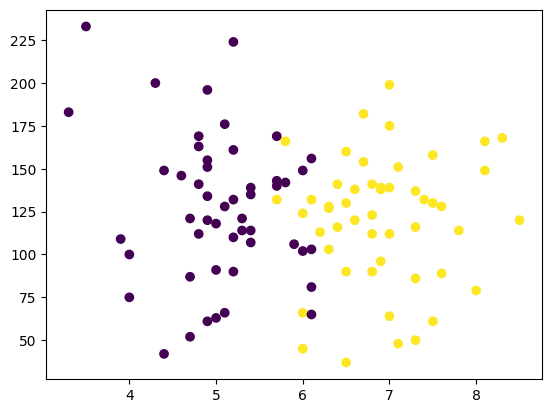

In [11]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [12]:
x = df.iloc[:,0:2]
y=df.iloc[:,-1]
x


,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [13]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2)
x_test


,cgpa,iq
47,5.2,161.0
26,7.0,199.0
22,4.9,120.0
86,5.1,128.0
88,4.4,149.0
33,6.0,149.0
3,7.4,132.0
29,7.0,112.0
1,5.9,106.0
24,4.7,121.0


In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_test

array([[-0.7535325 ,  0.98421175],
       [ 0.83053582,  1.94875196],
       [-1.01754388, -0.05647637],
       [-0.84153629,  0.14658473],
       [-1.45756286,  0.67962011],
       [-0.04950213,  0.67962011],
       [ 1.182551  ,  0.24811528],
       [ 0.83053582, -0.25953746],
       [-0.13750593, -0.41183329],
       [-1.19355147, -0.03109373],
       [ 0.30251305,  0.47655901],
       [-1.80957804, -0.56412911],
       [ 0.83053582,  0.42579374],
       [-2.24959702,  2.81176162],
       [-0.04950213, -0.51336384],
       [ 1.0945472 , -1.83326096],
       [ 0.03850166, -0.4879812 ],
       [ 0.39051684,  0.95882912],
       [-1.01754388, -1.55405196],
       [-0.6655287 , -0.20877219]])

In [16]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
#model training
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [17]:
y_test

,placement
47,0
26,1
22,0
86,0
88,0
33,0
3,1
29,1
1,0
24,0


In [18]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8

<Axes: >

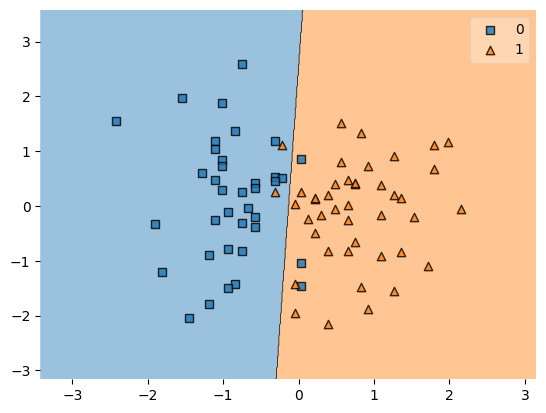

In [19]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x_train,y_train.values,clf=model)

In [20]:
import pickle
pickle.dump(model,open('model.pkl','wb'))